In [1]:
import json, glob
import pandas as pd
from pathlib import Path

def load_runs(pattern):
    """One row per run: tag, seed, best step, training time and every validation metric from its JSON."""
    rows = []
    for f in sorted(glob.glob(pattern)):
        d = json.loads(Path(f).read_text())
        a = d["args"]
        rows.append({"tag": a.get("tag") or "control (trial 2)", "seed": a["seed"],
                     "best_step": d["best_step"], "score": d["best_score"],
                     "time_s": d["train_seconds"], **d["best_val_metrics"]})
    return pd.DataFrame(rows)

df = pd.concat([load_runs("../Trial_2_results/results/timegan_con_s*.json"),
                load_runs("results/timegan_con_*.json")], ignore_index=True)

cols = ["score", "KL spread vs real", "KL returns vs real", "Any invariant broken (%)",
        "Windows trending up (%)", "best_step", "time_s"]
cols = [c for c in cols if c in df.columns]          # skip any metric a JSON doesn't have

print("Per-seed results (validation, best checkpoint):")
display(df[["tag", "seed"] + cols].round(3))

summary = df.groupby("tag")[cols].agg(["mean", "std"]).round(3)
print("\nMean ± std over 3 seeds. Lower is better for score and KLs; trend up should be near 50%.")
print("len60 and lvl5 are scored on different windows/features, so compare them with care.")
display(summary)

Per-seed results (validation, best checkpoint):


,tag,seed,score,KL spread vs real,KL returns vs real,Any invariant broken (%),Windows trending up (%),best_step,time_s
0,control (trial 2),0,0.763,0.163,0.561,0.0,46.055,3750,276.6
1,control (trial 2),1,0.666,0.117,0.494,0.0,44.476,4250,275.2
2,control (trial 2),2,0.558,0.191,0.365,0.0,49.785,500,274.4
3,ae10k,0,0.708,0.123,0.523,0.0,43.902,4500,314.0
4,ae10k,1,0.662,0.078,0.518,0.0,43.472,3750,316.5
5,ae10k,2,0.683,0.128,0.502,0.0,44.620,4250,314.4
6,len60,0,0.662,0.155,0.501,0.0,49.319,4500,279.2
7,len60,1,0.652,0.198,0.426,0.0,47.201,1750,276.7
8,len60,2,0.615,0.075,0.521,0.0,51.891,1000,279.7
9,lrj1e-4,0,0.864,0.278,0.517,0.0,56.958,750,274.6



Mean ± std over 3 seeds. Lower is better for score and KLs; trend up should be near 50%.
len60 and lvl5 are scored on different windows/features, so compare them with care.


score        KL spread vs real        KL returns vs real  \
                    mean    std              mean    std               mean   
tag                                                                           
ae10k              0.684  0.023             0.110  0.027              0.514   
control (trial 2)  0.662  0.103             0.157  0.037              0.473   
len60              0.643  0.025             0.143  0.062              0.483   
lrj1e-4            0.774  0.091             0.242  0.076              0.496   
lvl5               0.626  0.107             0.128  0.033              0.437   

                         Any invariant broken (%)       \
                     std                     mean  std   
tag                                                      
ae10k              0.011                      0.0  0.0   
control (trial 2)  0.100                      0.0  0.0   
len60              0.050                      0.0  0.0   
lrj1e-4            0.103                      0.0  0.0   
lvl5               0.124                      0.0  0.0   

                  Windows trending up (%)        best_step             time_s  \
                                     mean    std      mean       std     mean   
tag                                                                             
ae10k                              43.998  0.580  4166.667   381.881  314.967   
control (trial 2)                  46.772  2.726  2833.333  2036.132  275.400   
len60                              49.470  2.349  2416.667  1842.779  278.533   
lrj1e-4                            51.028  5.332  1916.667  2020.726  273.433   
lvl5                               50.980  8.106  1583.333  1892.969  271.067   

                          
                     std  
tag                       
ae10k              1.343  
control (trial 2)  1.114  
len60              1.607  
lrj1e-4            1.201  
lvl5               2.196

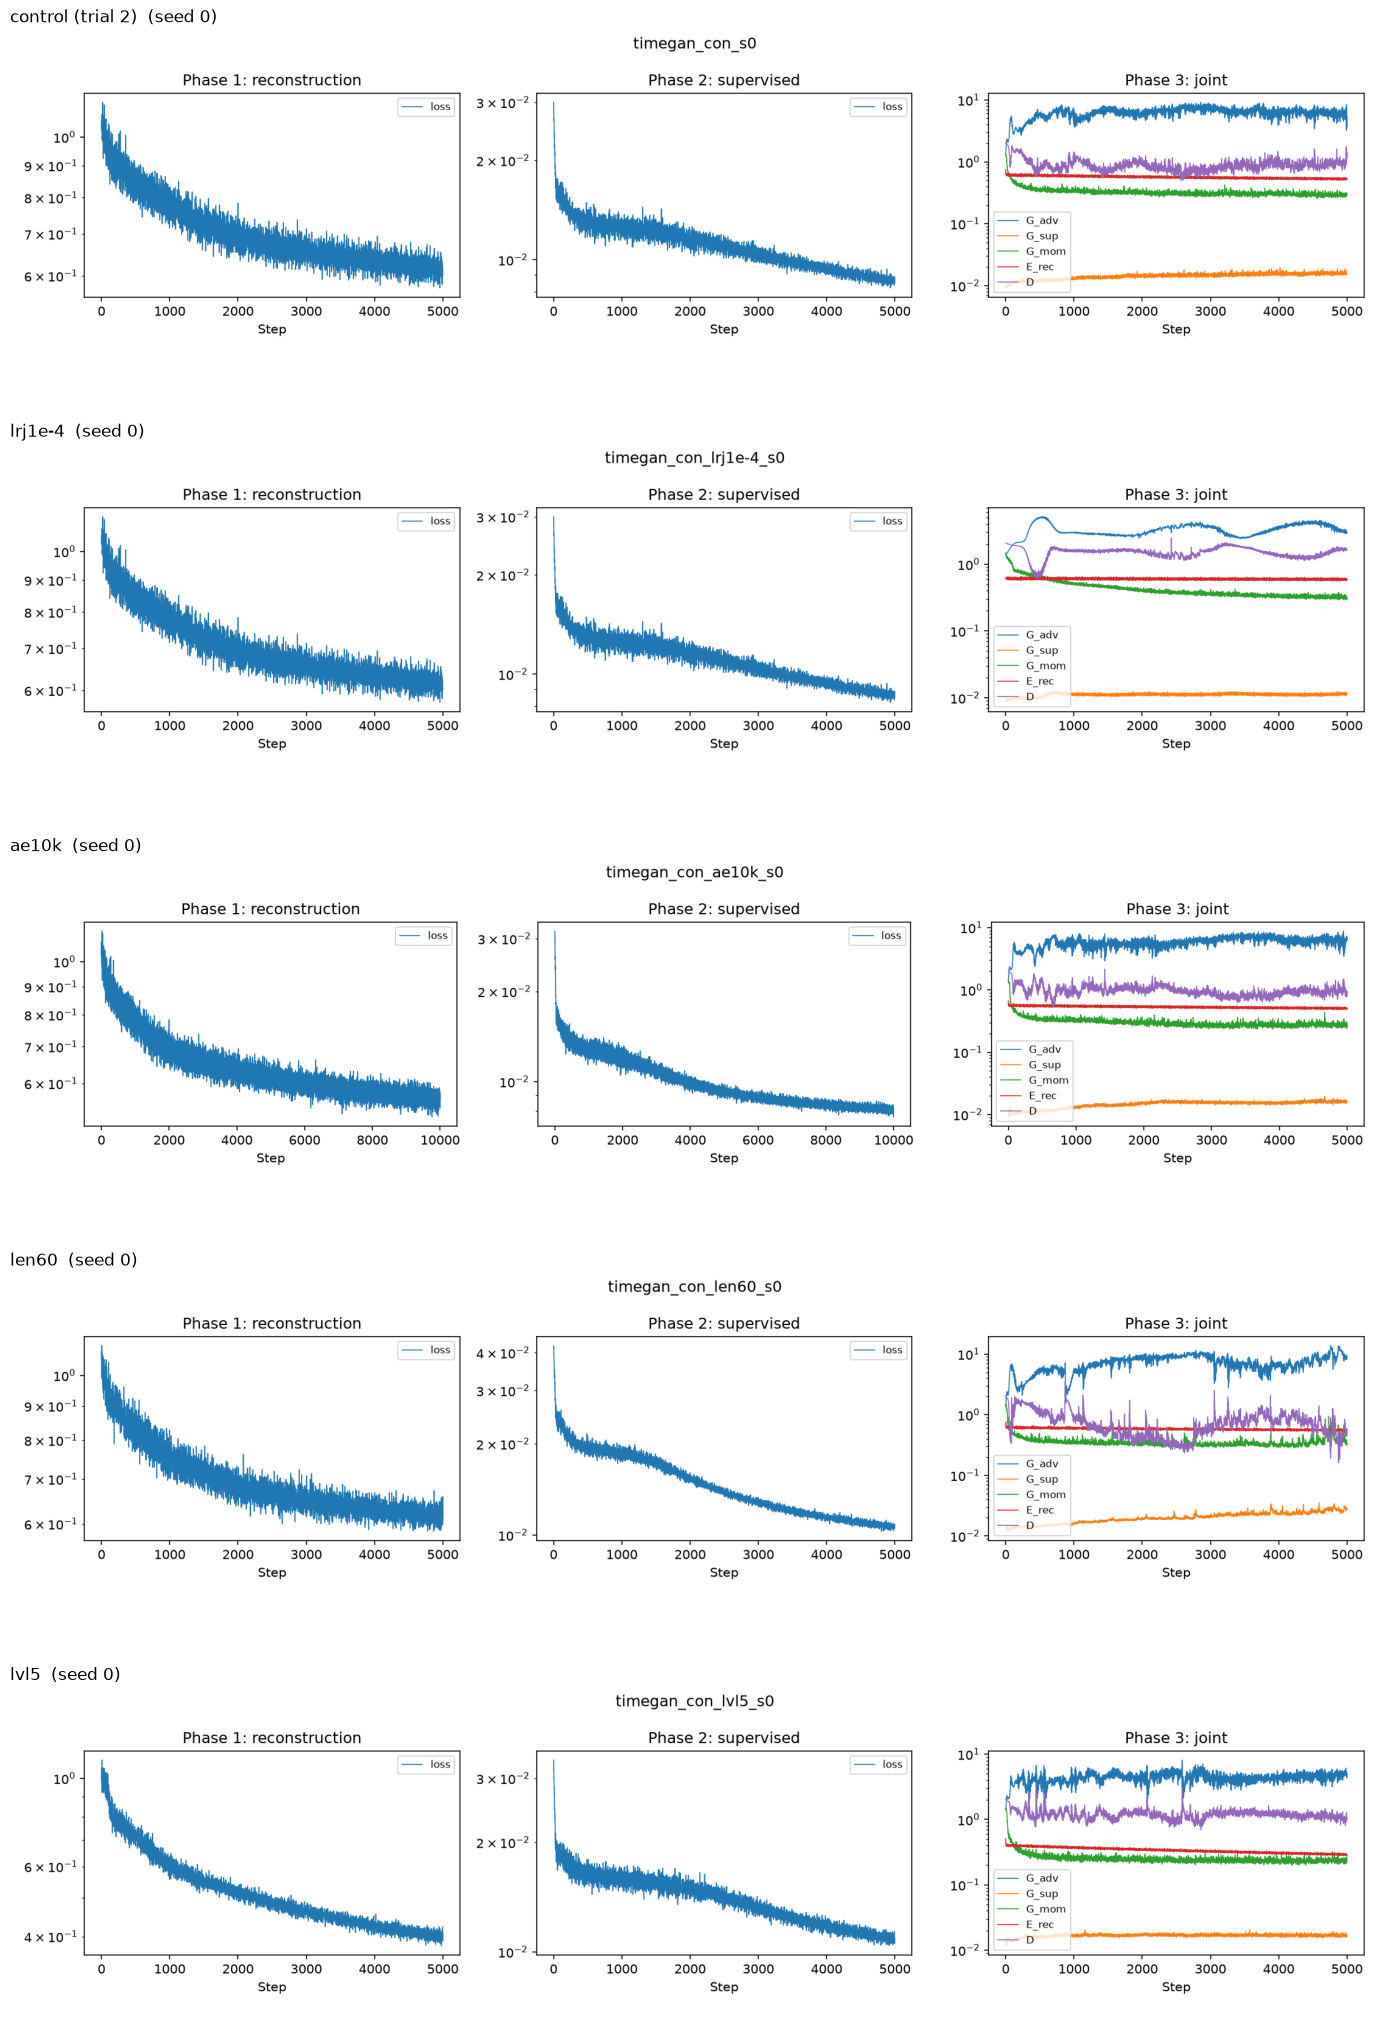

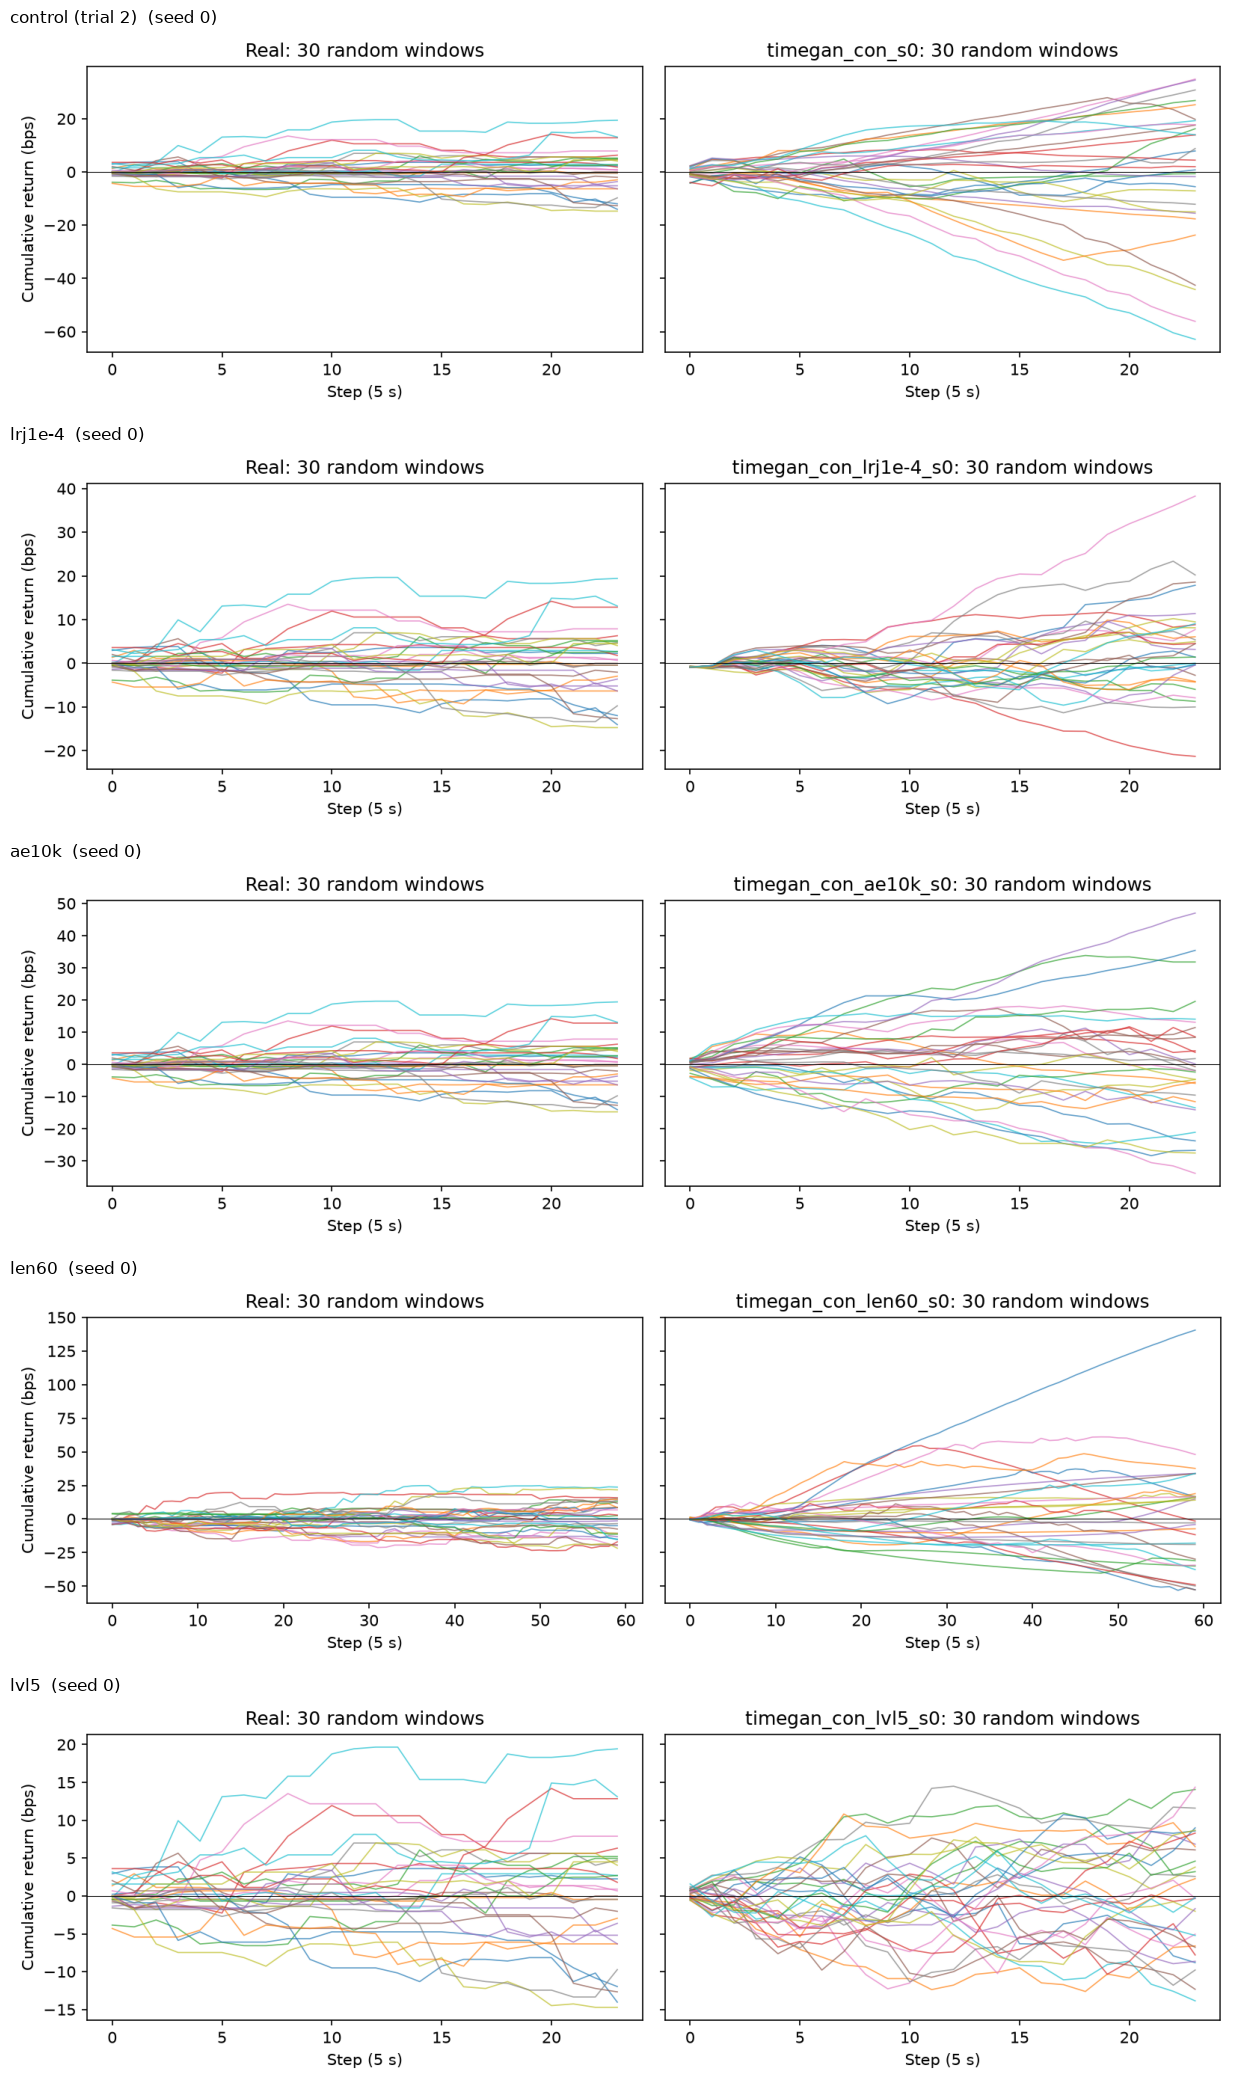

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

RUNS = {"control (trial 2)": "../Trial_2_results/figures/timegan_con_s{seed}_{kind}.png",
        "lrj1e-4": "figures/timegan_con_lrj1e-4_s{seed}_{kind}.png",
        "ae10k":   "figures/timegan_con_ae10k_s{seed}_{kind}.png",
        "len60":   "figures/timegan_con_len60_s{seed}_{kind}.png",
        "lvl5":    "figures/timegan_con_lvl5_s{seed}_{kind}.png"}

def show(kind, seed=0, save=True):
    """Stack the saved `kind` figure (losses / val_paths / val_dists / val_book) for every tag at one seed."""
    fig, axes = plt.subplots(len(RUNS), 1, figsize=(14, 4.2 * len(RUNS)))
    for ax, (tag, pattern) in zip(axes, RUNS.items()):
        path = pattern.format(seed=seed, kind=kind)
        if Path(path).exists():
            ax.imshow(mpimg.imread(path))
        else:
            ax.text(0.5, 0.5, f"missing: {path}", ha="center", va="center")
        ax.set_title(f"{tag}  (seed {seed})", fontsize=12, loc="left"); ax.axis("off")
    fig.tight_layout()
    if save:
        fig.savefig(f"figures/compare_{kind}_s{seed}.png", dpi=120, bbox_inches="tight")
    plt.show()

show("losses", seed=0)        # training dynamics: does phase 3 drift, does D stay active?
show("val_paths", seed=0)     # generation: 30 return paths, real vs generated

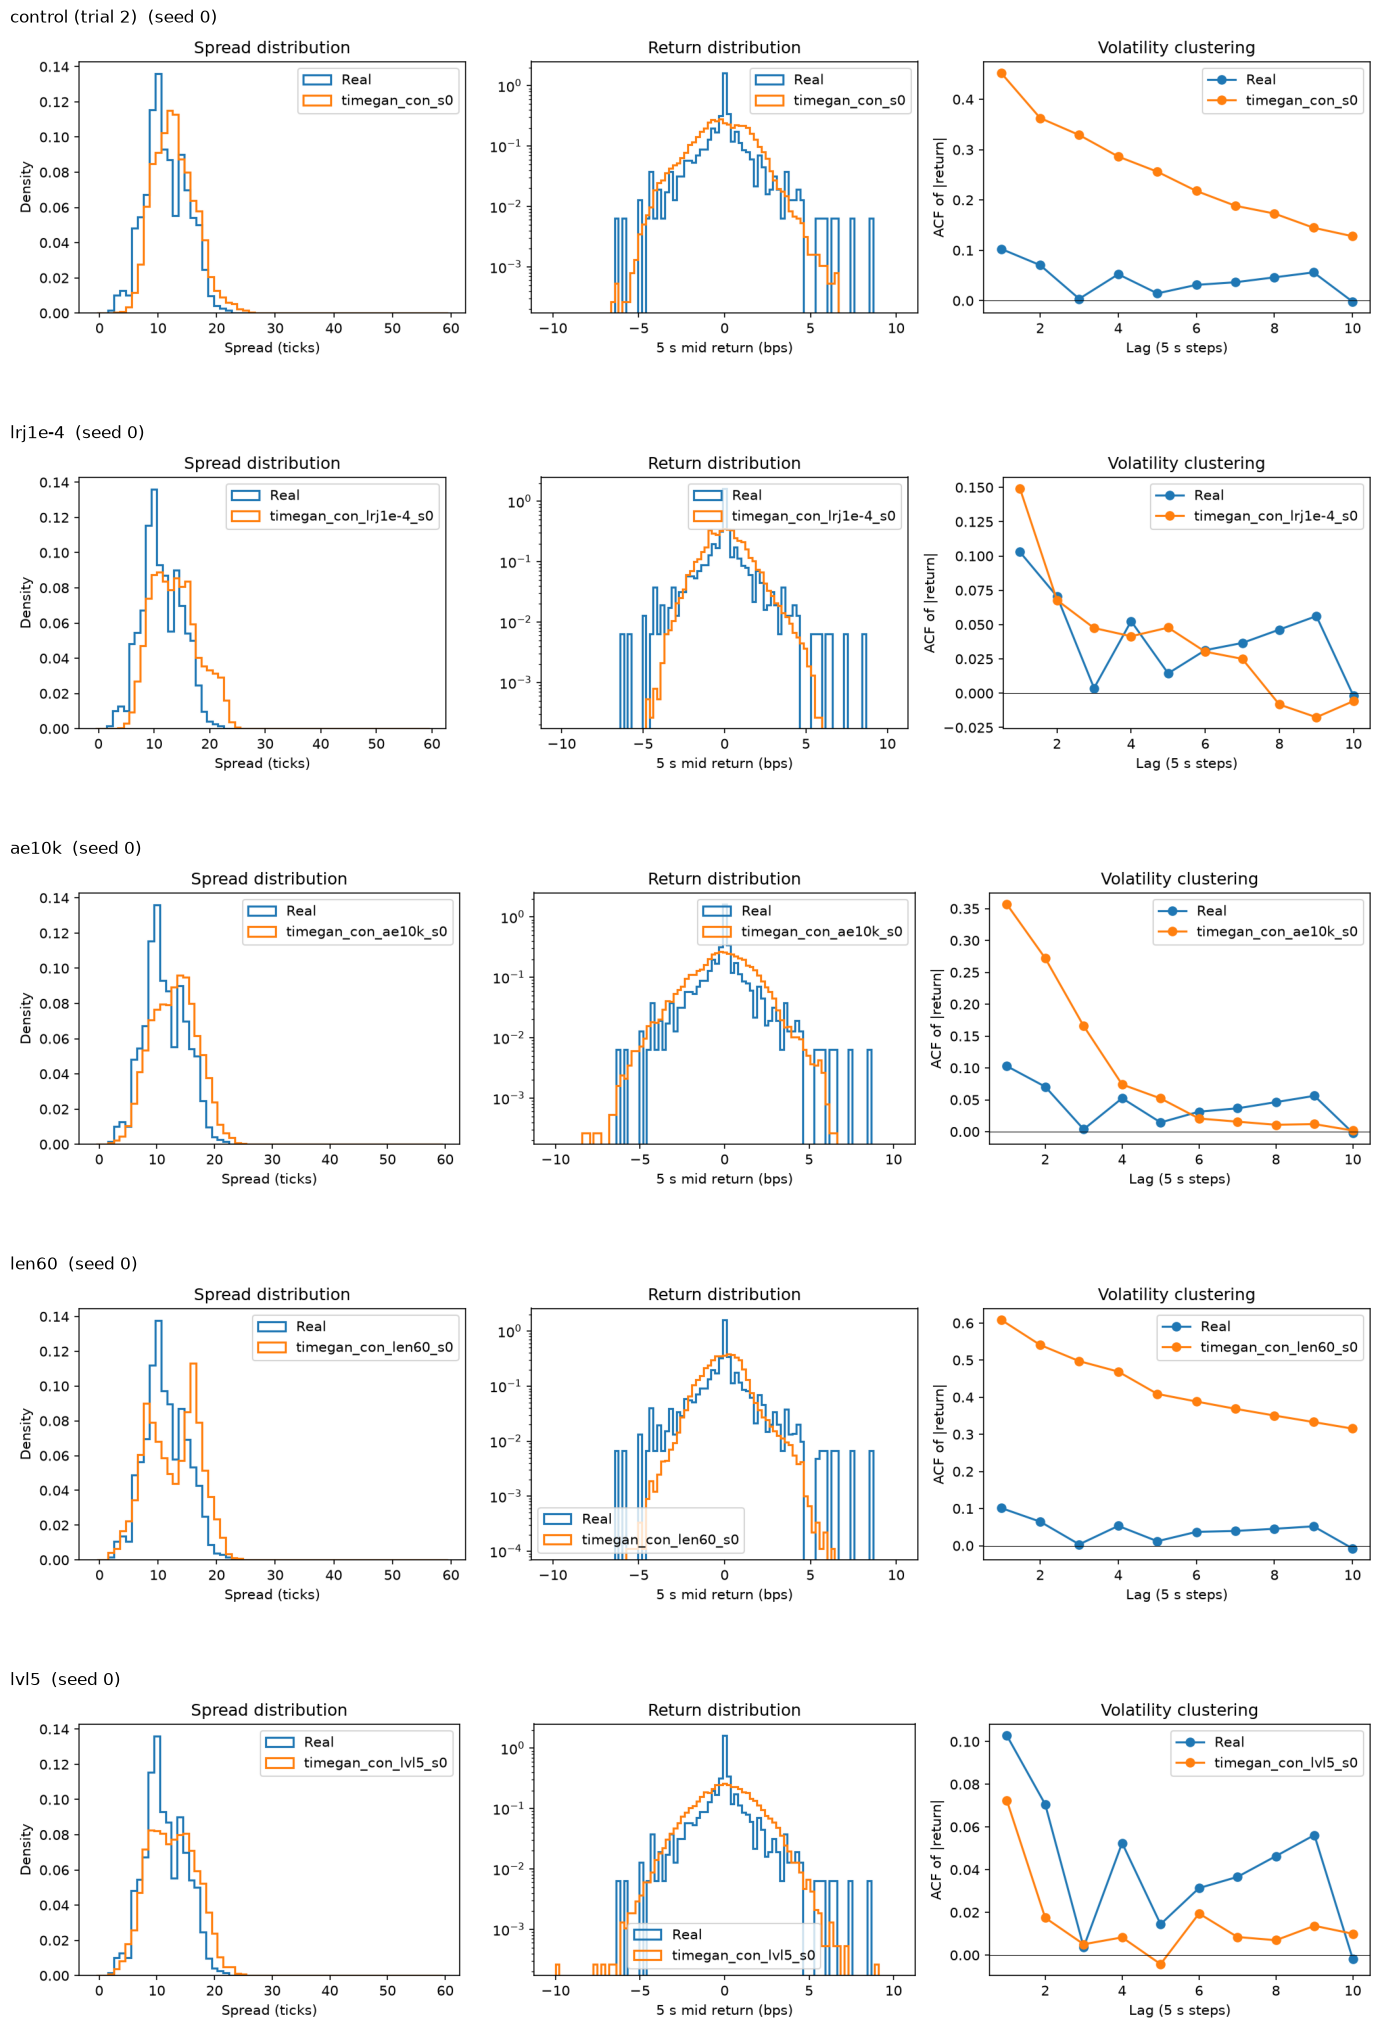

In [3]:
show("val_dists", seed=0)

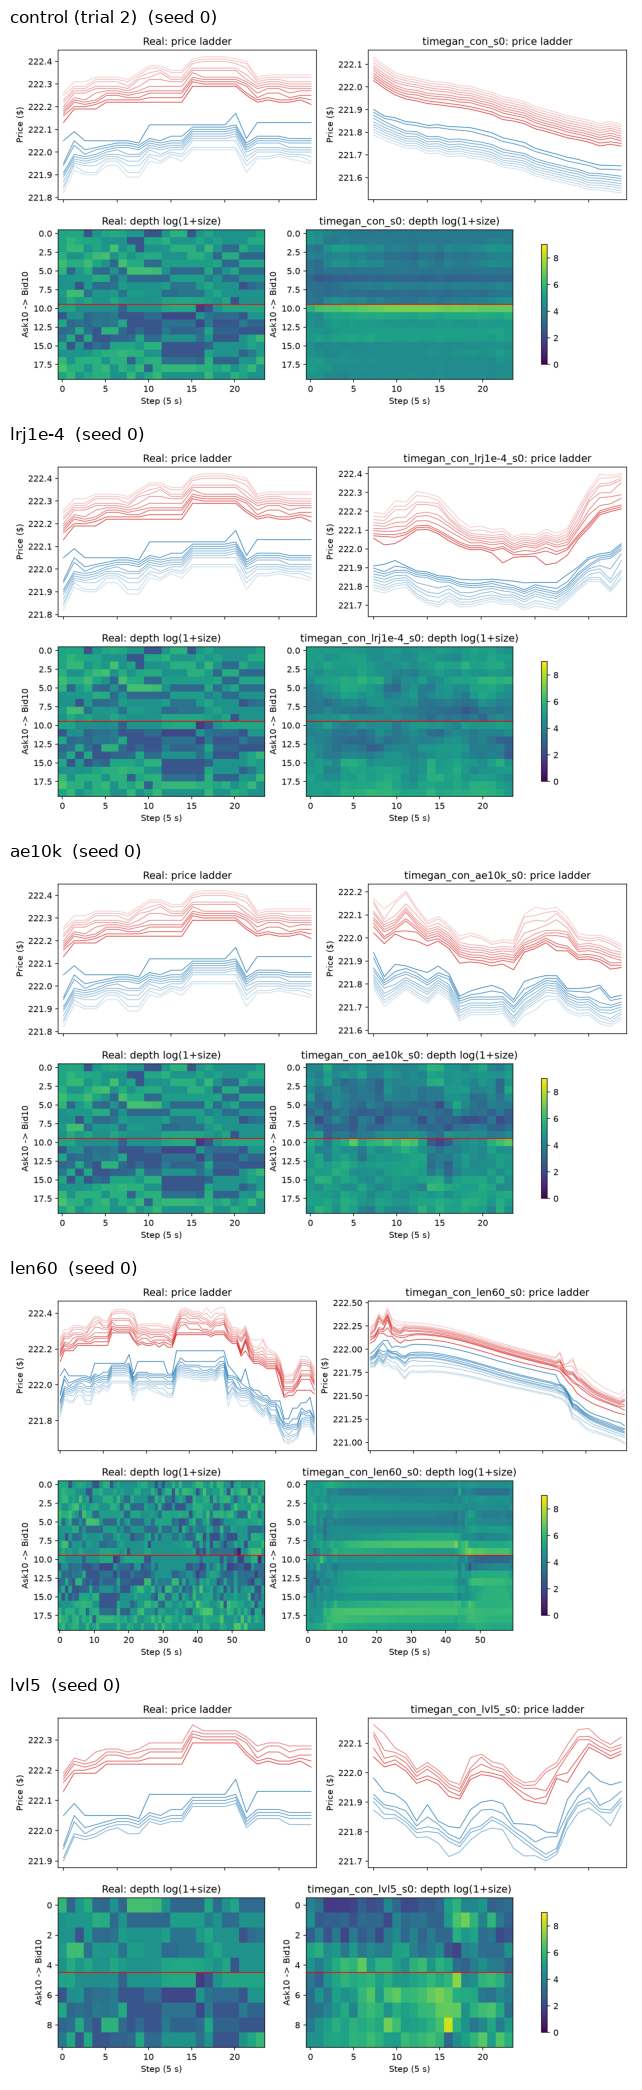

In [8]:
show("val_book", seed=0)

In [6]:
import sys, subprocess, torch, torch.nn as nn
sys.path.insert(0, "..")
import utils
from dataset import get_data
from modules import TGGenerator, TGSupervisor, TGRecovery, ConstrainedHead, tg_generate

DATA = Path.home() / "Desktop/LOBSTER"
COMMIT = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True).stdout.strip()
print("code version:", COMMIT)

_val_cache = {}
def val_windows(seq_len, level):
    """Validation windows for a run's own window length and depth (cached)."""
    if (seq_len, level) not in _val_cache:
        _, v, _, s = get_data(str(DATA), seq_len=seq_len, level=level)
        _val_cache[(seq_len, level)] = (v, s)
    return _val_cache[(seq_len, level)]

def load_tg(path):
    """Rebuild G, S, R (+ head) with the shapes stored in the checkpoint, load weights."""
    ck = torch.load(path, weights_only=False, map_location="cpu")
    a, stats = ck["args"], ck["stats"]
    cols = list(stats["mean"].index)
    R = TGRecovery(n_features=len(cols))
    if a.get("constrained"):
        pos = [cols.index("spread")] + [i for i, c in enumerate(cols) if "gap" in c]
        vol = [i for i, c in enumerate(cols) if "logv" in c]
        R = nn.Sequential(R, ConstrainedHead(torch.tensor(stats["mean"].to_numpy()),
                                             torch.tensor(stats["std"].to_numpy()), pos, vol))
    G, S = TGGenerator(), TGSupervisor()
    for name, net in {"G": G, "S": S, "R": R}.items():
        net.load_state_dict(ck[name]); net.eval()
    return G, S, R, a, stats

CKPTS = {"control (trial 2)": "../Trial_2_results/checkpoints/timegan_con_s{seed}.pt",
         **{t: f"checkpoints/timegan_con_{t}_s{{seed}}.pt" for t in ["lrj1e-4", "ae10k", "len60", "lvl5"]}}
KEEP = ["KL spread vs real", "KL returns vs real", "Zero returns (%)",
        "Vol clustering: ACF |ret| lag 1", "Any invariant broken (%)"]

rows = []
for tag, pattern in CKPTS.items():
    for seed in range(3):
        G, S, R, a, stats_ck = load_tg(pattern.format(seed=seed))
        seq_len, level = a.get("seq_len", 24), a.get("level", 10)
        val_w, stats = val_windows(seq_len, level)
        torch.manual_seed(1234)                                   # same noise as checkpoint selection
        fake = tg_generate(G, S, R, len(val_w), seq_len=seq_len)
        snapped = utils.snap_windows(fake, stats)
        for version, w in [("raw", fake), ("snapped", snapped)]:
            m = utils.evaluate(val_w, w, stats, ssim=False)
            rows.append({"tag": tag, "seed": seed, "version": version,
                         **{k: m["fake"][k] for k in KEEP},
                         "real zero returns (%)": m["real"]["Zero returns (%)"],
                         "real ACF lag 1": m["real"]["Vol clustering: ACF |ret| lag 1"]})
        if seed == 0:
            utils.plot_distributions(val_w, snapped, stats, label=f"{tag} snapped",
                                     path=f"figures/snapped_{tag}_s0_dists.png")
            utils.plot_book_comparison(val_w, snapped, stats, label=f"{tag} snapped",
                                       path=f"figures/snapped_{tag}_s0_book.png")
            plt.close("all")

snap_df = pd.DataFrame(rows)
snap_df.to_csv(f"results/snapping_{COMMIT}.csv", index=False)     # saved with the code version in the name
print("Mean over 3 seeds, raw vs snapped (validation). Real zero returns and ACF shown for reference.")
display(snap_df.groupby(["tag", "version"])[KEEP + ["real zero returns (%)", "real ACF lag 1"]].mean().round(3))

code version: 37b5004
Mean over 3 seeds, raw vs snapped (validation). Real zero returns and ACF shown for reference.


KL spread vs real  KL returns vs real  \
tag               version                                          
ae10k             raw                  0.110               0.518   
                  snapped              0.110               0.522   
control (trial 2) raw                  0.154               0.489   
                  snapped              0.154               0.470   
len60             raw                  0.143               0.498   
                  snapped              0.143               0.508   
lrj1e-4           raw                  0.260               0.488   
                  snapped              0.260               0.497   
lvl5              raw                  0.135               0.428   
                  snapped              0.135               0.435   

                           Zero returns (%)  Vol clustering: ACF |ret| lag 1  \
tag               version                                                      
ae10k             raw                 6.080                            0.248   
                  snapped             6.048                            0.238   
control (trial 2) raw                 7.381                            0.455   
                  snapped             7.985                            0.437   
len60             raw                 7.421                            0.502   
                  snapped             8.713                            0.467   
lrj1e-4           raw                 8.867                            0.398   
                  snapped             8.531                            0.376   
lvl5              raw                 8.078                            0.192   
                  snapped             7.917                            0.186   

                           Any invariant broken (%)  real zero returns (%)  \
tag               version                                                    
ae10k             raw                           0.0                 36.585   
                  snapped                       0.0                 36.585   
control (trial 2) raw                           0.0                 36.585   
                  snapped                       0.0                 36.585   
len60             raw                           0.0                 36.084   
                  snapped                       0.0                 36.084   
lrj1e-4           raw                           0.0                 36.585   
                  snapped                       0.0                 36.585   
lvl5              raw                           0.0                 36.585   
                  snapped                       0.0                 36.585   

                           real ACF lag 1  
tag               version                  
ae10k             raw               0.103  
                  snapped           0.103  
control (trial 2) raw               0.103  
                  snapped           0.103  
len60             raw               0.102  
                  snapped           0.102  
lrj1e-4           raw               0.103  
                  snapped           0.103  
lvl5              raw               0.103  
                  snapped           0.103

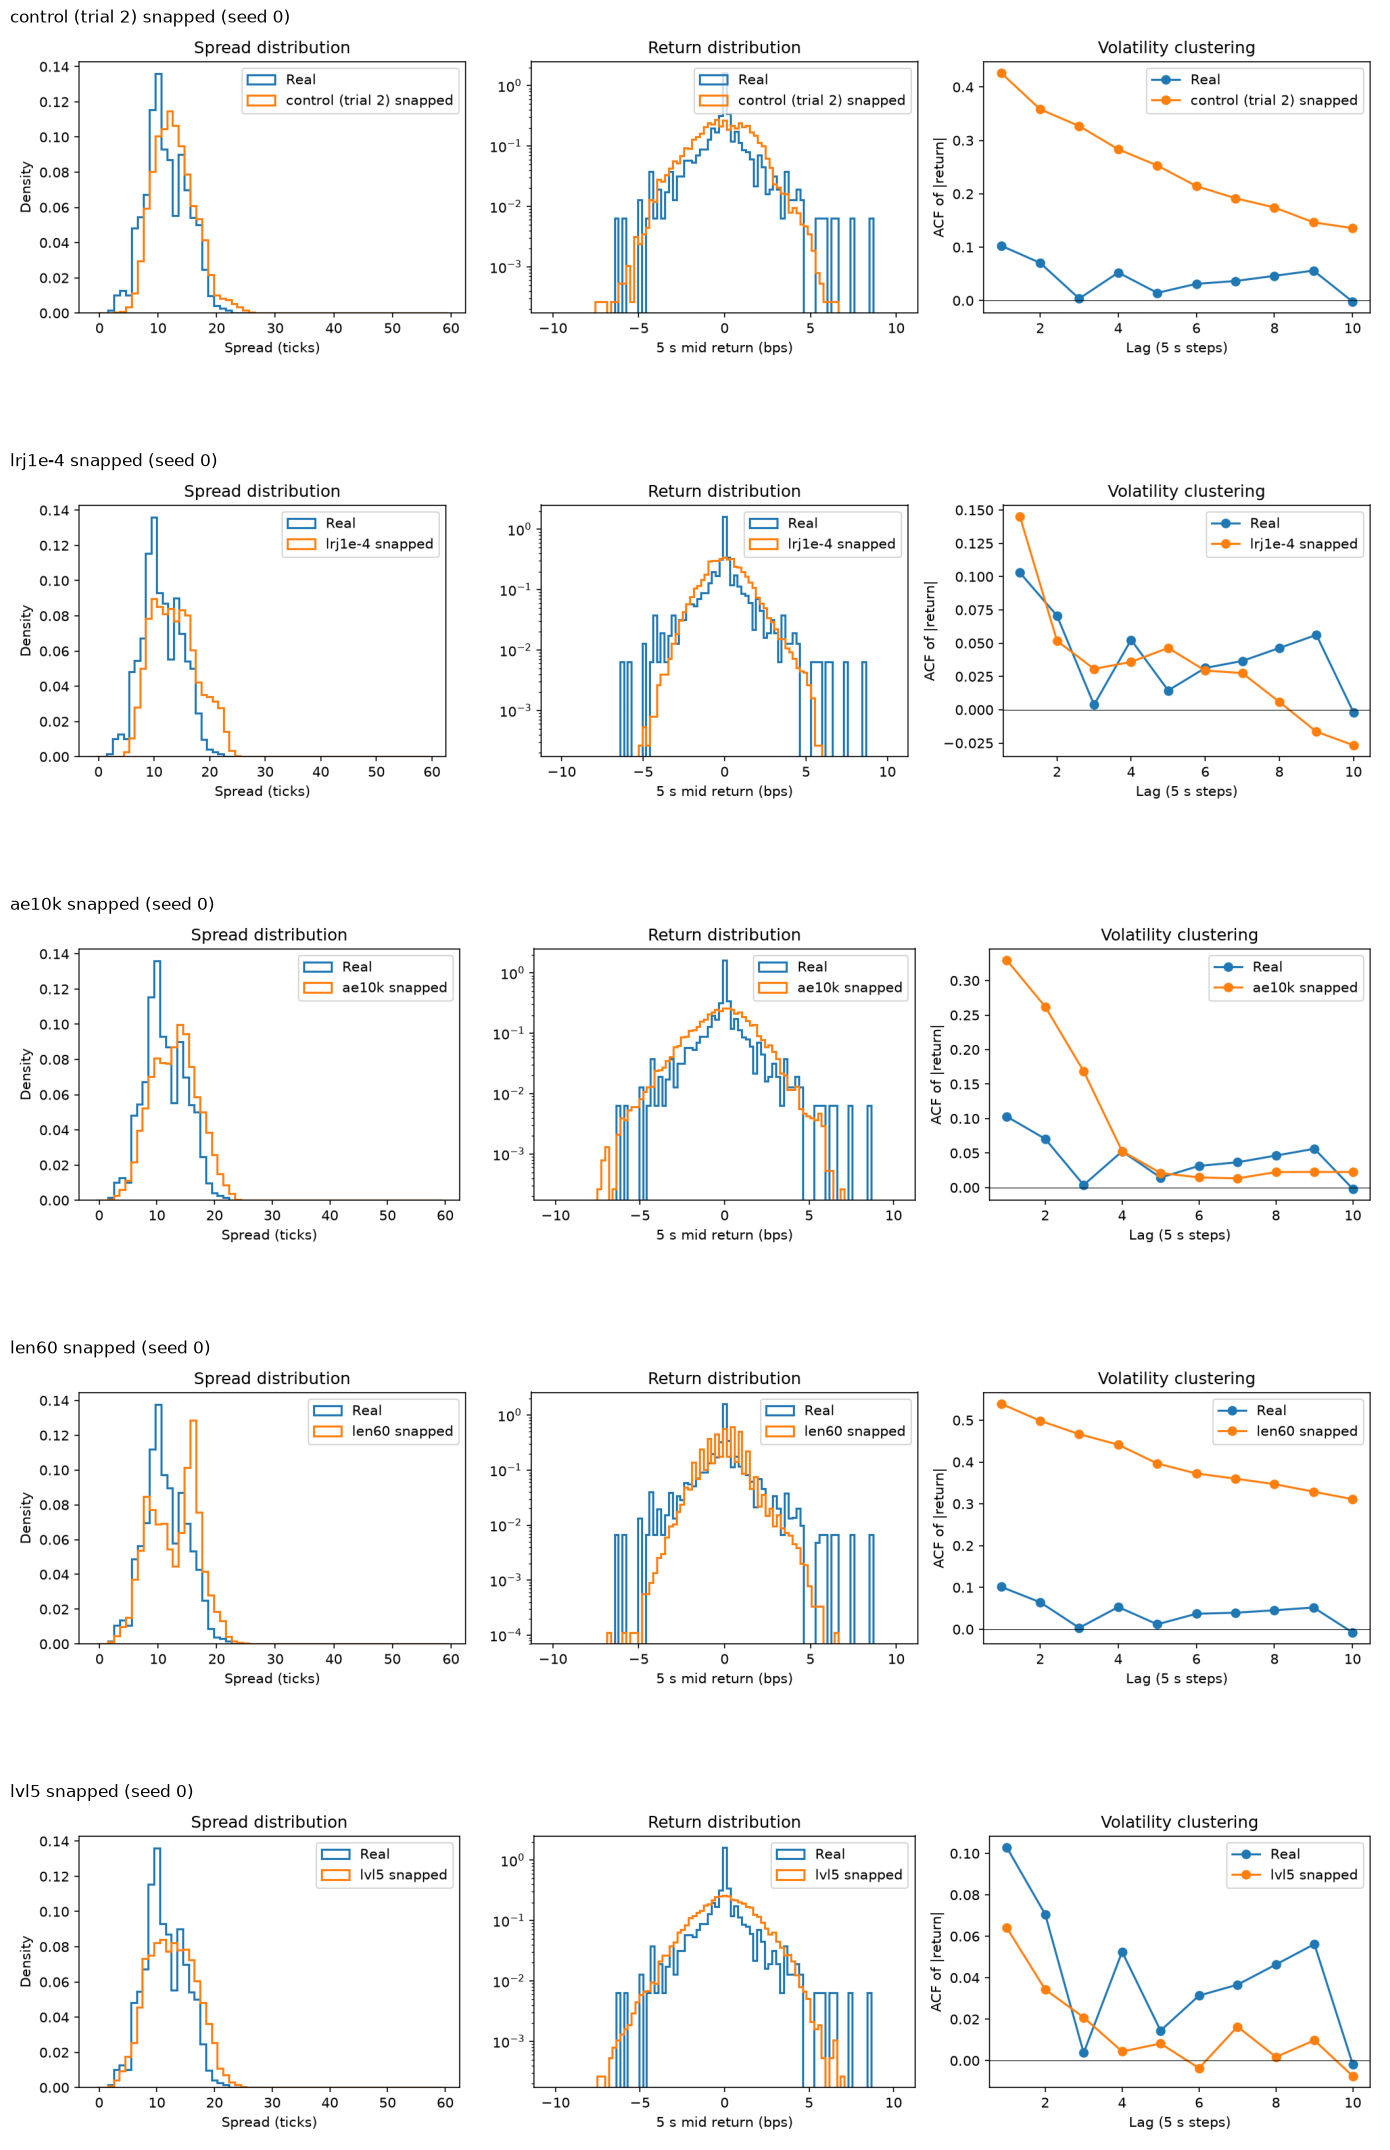

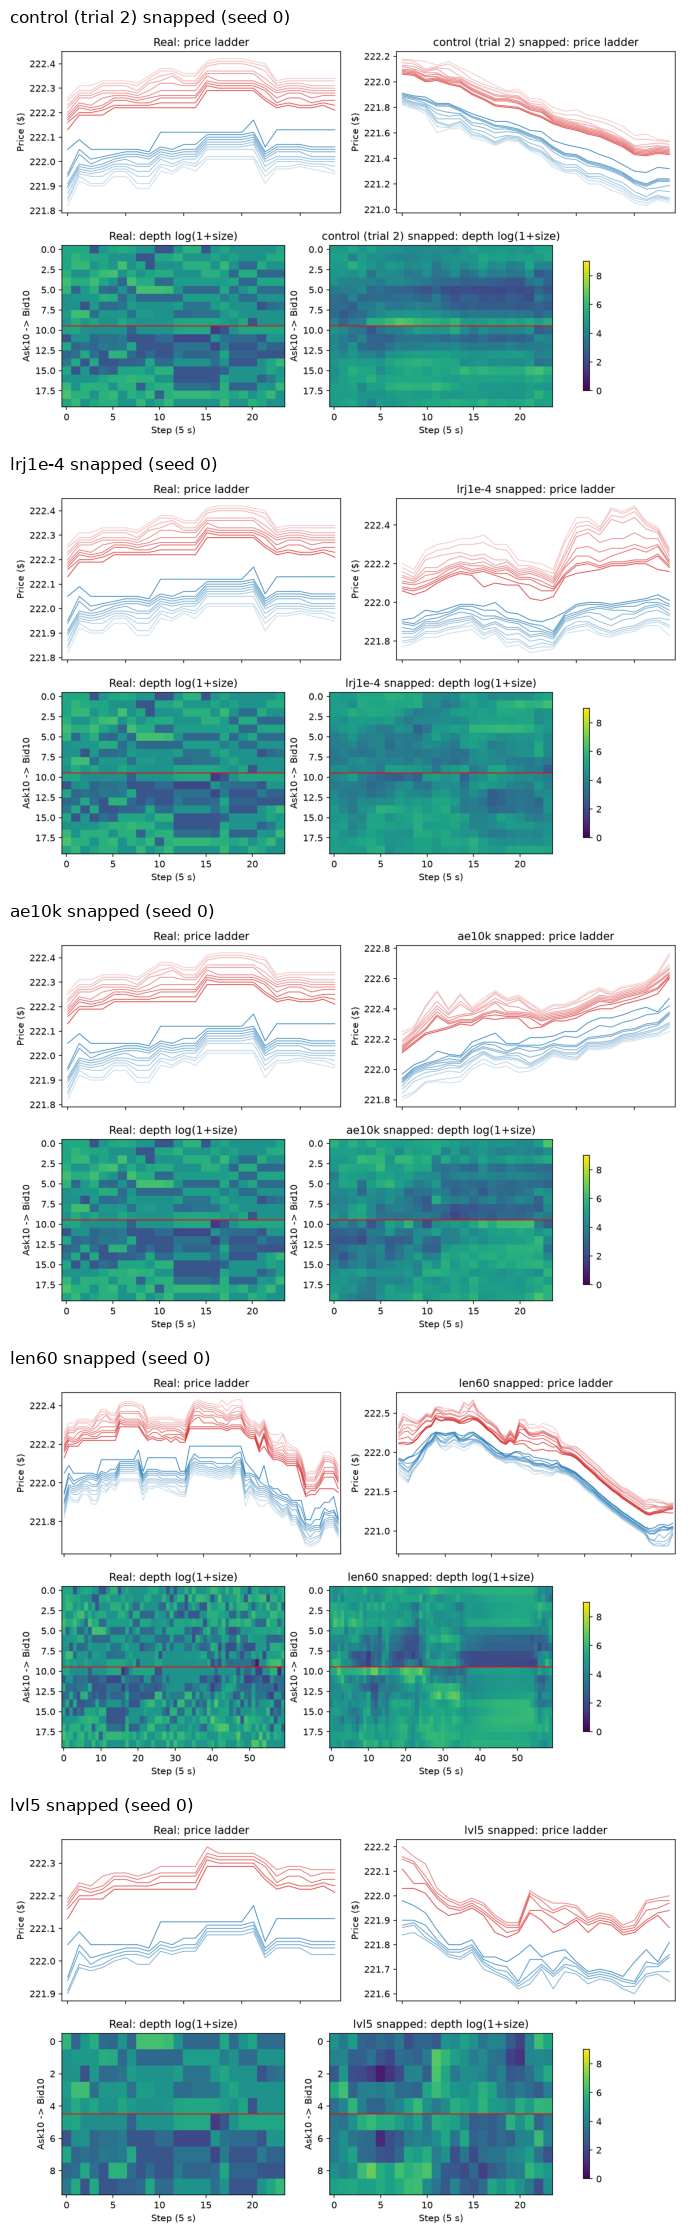

In [7]:
def show_snapped(kind):
    """Stack the snapped `kind` figure (dists / book) for every tag, seed 0."""
    fig, axes = plt.subplots(len(CKPTS), 1, figsize=(14, 4.5 * len(CKPTS)))
    for ax, tag in zip(axes, CKPTS):
        ax.imshow(mpimg.imread(f"figures/snapped_{tag}_s0_{kind}.png"))
        ax.set_title(f"{tag} snapped (seed 0)", fontsize=12, loc="left"); ax.axis("off")
    fig.tight_layout()
    fig.savefig(f"figures/compare_snapped_{kind}_s0.png", dpi=120, bbox_inches="tight")
    plt.show()

show_snapped("dists")
show_snapped("book")